
<style>
/* --- Notebook-wide typography and spacing --- */
.jp-RenderedHTMLCommon, .rendered_html, .bd-article, .nbinput, .nboutput {
  --toy-max-width: 980px;
}

.jp-RenderedHTMLCommon p, .rendered_html p, .bd-article p {
  line-height: 1.65;
  font-size: 1.02rem;
  margin-top: 0.35rem;
  margin-bottom: 0.9rem;
}

.jp-RenderedHTMLCommon h2, .rendered_html h2, .bd-article h2 {
  font-size: 2.05rem;
  line-height: 1.2;
  margin-top: 0.2rem;
  margin-bottom: 0.35rem;
  padding-bottom: 0.2rem;
  border-bottom: 1px solid rgba(128,128,128,0.18);
}

.jp-RenderedHTMLCommon h3, .rendered_html h3, .bd-article h3 {
  font-size: 1.45rem;
  line-height: 1.3;
  margin-top: 1.9rem;
  margin-bottom: 0.55rem;
}

.jp-RenderedHTMLCommon h4, .rendered_html h4, .bd-article h4 {
  font-size: 1.15rem;
  line-height: 1.35;
  margin-top: 1.35rem;
  margin-bottom: 0.45rem;
}

.jp-RenderedHTMLCommon ul, .rendered_html ul, .bd-article ul {
  margin-top: 0.35rem;
  margin-bottom: 0.95rem;
  padding-left: 1.4rem;
}

.jp-RenderedHTMLCommon li, .rendered_html li, .bd-article li {
  margin-bottom: 0.3rem;
  line-height: 1.6;
}

/* --- Code cells and outputs --- */
div.input_area, .jp-Cell-inputWrapper, .highlight, pre {
  border-radius: 12px;
}

.jp-CodeCell .jp-InputArea-editor, .input_area, div.highlight {
  font-size: 0.96rem;
}

.output_subarea, .jp-OutputArea-output {
  max-width: 100%;
}

.jp-OutputArea-output img, .output_subarea img {
  display: block;
  margin-left: auto;
  margin-right: auto;
  border-radius: 10px;
}

/* --- Visual polish --- */
hr {
  margin-top: 1.5rem !important;
  margin-bottom: 1.5rem !important;
}

blockquote {
  border-left: 4px solid rgba(59,130,246,0.55);
  margin: 1rem 0;
  padding: 0.25rem 0 0.25rem 1rem;
  background: rgba(59,130,246,0.06);
  border-radius: 0 10px 10px 0;
}

/* --- Keep content comfortably narrow in rendered contexts --- */
.jp-Notebook .jp-Cell, .notebook_app .cell, .bd-article {
  max-width: 980px;
}

/* --- Slightly more breathing room between cells --- */
.jp-Cell, .cell {
  margin-top: 0.45rem;
  margin-bottom: 0.45rem;
}
</style>


# Phase-type models for tract length distributions

In this tutorial, we illustrate how to use the functions in ``tracts`` to compute and depict tract length distributions under the different models of admixture introduced in the paper. These are, in increasing order of complexity:

* The Monoecious (M) model (only defined for autosomal admixture),
* The Dioecious-Coarse (DC) model,
* The Dioecious-Fine (DF) model,
* The hybrid-pedidree refinements of the DC (H-DC) and the DF (H-DF) models.

We start by importing the required python libraries:

In [ ]:
from tracts.phase_type import PhTMonoecious, PhTDioecious
from tracts.phase_type import hybrid_pedigree as HP
from tracts.phase_type.plot import plot_tractlength_density, plot_tractlength_histogram
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

The notebook will illustrate the implementation of the following diagram, for different admixture models and transmission scenarios:

![Phase-type model diagram](phasetype.png)

Throughout this notebook, we consider two source populations and a **continuous pulse** from the first to the second. This can be represented with the following migration matrix. The `whichpop` parameter sets the population of interest (0 or 1), that is, from which the tract length distribution is to be computed.

In [2]:
whichpop = 1
mig_matrix = np.array([[0, 0],[0.2, 0],[0.2, 0],[0.2, 0],[0.2, 0],[0.2, 0],[0, 1]])

## 1. Choose transmission

In [1]:
X_chr = False # Set to True for admixture on the X chromosome
X_chr_male = False # Set to True if admixture is considered on the X chromosome of a male individual (only maternally inherited alleles).

In [ ]:
which_L = 1.7928357829 # Second chromosome
#which_L = 1.96 # For the X chromosome
# Set a point grid on the finite chromosome
bins = np.linspace(0, which_L+0.1, num = 50)

## 2. Set sex-bias

In [5]:
sex_bias = 0 # Sex-bias parameter, from -1 (exclusively male migration) to 1 (exclusively female migration). 0 corresponds to unbiased migration.
mig_f = mig_matrix + sex_bias*np.minimum(mig_matrix, 1-mig_matrix) # Female-specific migration matrix
mig_m = mig_matrix - sex_bias*np.minimum(mig_matrix, 1-mig_matrix) # Male-specific migration matrix
mig_m[-1,:] = mig_matrix[-1,:]
mig_f[-1,:] = mig_matrix[-1,:]

rho_f = 1 # Female-specific recombination rate
rho_m = 1 # Male-specific recombination rate

## 3. Build Markov model

### 3.1 Monoecious model (only for autosomal admixture)

In [ ]:
PTmodel_mono = PhTMonoecious(migration_matrix=mig_matrix,
                            rho = 0.5*(rho_f+rho_m)) # PhTMonoecious object


### 3.2 Dioecious Fine and Coarse models

In [ ]:
# PhTDioecious objects (DF and DC models)
PTmodel_DF = PhTDioecious(migration_matrix_f=mig_f,
                        migration_matrix_m=mig_m,
                        rho_f=rho_f,
                        rho_m=rho_m,
                        sex_model='DF',
                        X_chromosome=X_chr,
                        X_chromosome_male=X_chr_male)

PTmodel_DC = PhTDioecious(migration_matrix_f=mig_f,
                        migration_matrix_m=mig_m,
                        rho_f=rho_f,
                        rho_m=rho_m,
                        sex_model='DC',
                        X_chromosome=X_chr,
                        X_chromosome_male=X_chr_male)

## 4. Compute tract length distributions

### 4.1 Compute tract length density functions

In [ ]:
# Phase-Type density for the Monoecious (M) model
newbins, density_m, E = PTmodel_mono.tractlength_histogram_windowed(population_number=whichpop,
                                                                    bins=bins,
                                                                    L=which_L,
                                                                    density=True,
                                                                    freq=False)

# Phase-Type density for the Dioecious Fine (DF) model
newbins, density_df, E = PTmodel_DF.tractlength_histogram_windowed(population_number=whichpop,
                                                                bins=bins,
                                                                L=which_L,
                                                                density=True,

                                                                freq=False)

# Phase-Type density for the Dioecious Coarse (DC) model
newbins, density_dc, E = PTmodel_DC.tractlength_histogram_windowed(population_number=whichpop,
                                                                bins=bins,
                                                                L=which_L,
                                                                density=True,
                                                                freq=False)

### 4.2 Compute tract length histograms

In [ ]:


# Tract length histogram for the Monoecious (M) model
bins, hist_m, E = PTmodel_mono.tractlength_histogram_windowed(population_number=whichpop,
                                                            bins=bins,
                                                            L=which_L,
                                                            density=False)

# Tract length histogram for the Dioecious Fine (DF) model
bins, hist_df, E = PTmodel_DF.tractlength_histogram_windowed(population_number=whichpop,
                                                            bins=bins,
                                                            L=which_L,
                                                            density=False)

# Tract length histogram for the Dioecious Coarse (DC) model
bins, hist_dc, E = PTmodel_DC.tractlength_histogram_windowed(population_number=whichpop,
                                                            bins=bins,
                                                            L=which_L,
                                                            density=False)

## 5. Hybrid-pedigree refinements

## 5.1 Phase-type mixture density functions

In [ ]:
# Phase-Type mixture density for the H-DF model (set freq = True for frequency scale)
newbins, density_hp_df = HP.hybrid_pedigree_distribution(mig_matrix_f=mig_f,
                                                        mig_matrix_m=mig_m,
                                                        TP=2,
                                                        Dioecious_model='DF',
                                                        L=which_L,
                                                        bingrid=bins,
                                                        whichpop=whichpop,
                                                        rho_f=rho_f,
                                                        rho_m=rho_m,
                                                        X_chr=X_chr,
                                                        X_chr_male=X_chr_male,
                                                        N_cores=5,
                                                        density=True,
                                                        freq=False)

# Phase-Type mixture density for the H-DC model (set freq = True for frequency scale)
newbins, density_hp_dc = HP.hybrid_pedigree_distribution(mig_matrix_f=mig_f,
                                                        mig_matrix_m=mig_m,
                                                        TP=2,
                                                        Dioecious_model='DC',
                                                        L=which_L,
                                                        bingrid=bins,
                                                        whichpop=whichpop,
                                                        rho_f=rho_f,
                                                        rho_m=rho_m,
                                                        X_chr=X_chr,
                                                        X_chr_male=X_chr_male,
                                                        N_cores=5,
                                                        density=True,
                                                        freq=False)

## 5.2 Tract length histograms for phase-type mixtures

In [ ]:

# Phase-Type mixture histogram for the H-DF model
bins, hist_hp_df = HP.hybrid_pedigree_distribution(mig_matrix_f=mig_f,
                                                mig_matrix_m=mig_m,
                                                TP=2,
                                                Dioecious_model='DF',
                                                L=which_L,
                                                bingrid=bins,
                                                whichpop=whichpop,
                                                rho_f=rho_f,
                                                rho_m=rho_m,
                                                X_chr=X_chr,
                                                X_chr_male=X_chr_male,
                                                N_cores=5,
                                                density=False)

# Phase-Type mixture histogram for the H-DC model
bins, hist_hp_dc = HP.hybrid_pedigree_distribution(mig_matrix_f=mig_f,
                                                mig_matrix_m=mig_m,
                                                TP=2,
                                                Dioecious_model='DC',
                                                L=which_L,
                                                bingrid=bins,
                                                whichpop=whichpop,
                                                rho_f=rho_f,
                                                rho_m=rho_m,
                                                X_chr=X_chr,
                                                X_chr_male=X_chr_male,
                                                N_cores=5,
                                                density=False)

## 6. Plot tract length distributions

### 6.1 Plot densities

#### 6.1.1 Plot for autosomal admixture
The following code produces a figure depicting all the computed Phase-Type densities for autosomal admixture. Run if ``X_chr = False``.

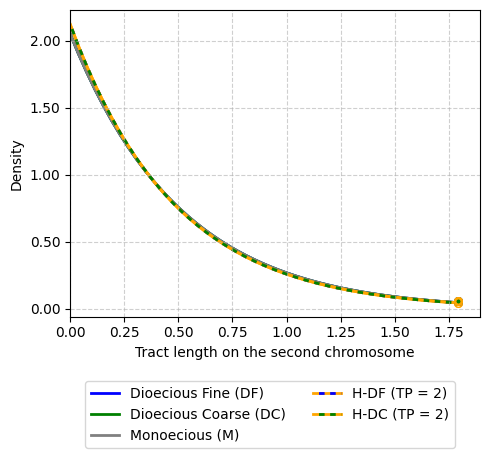

In [9]:
fig, ax = plot_tractlength_density(bins=newbins,
                                curves={'DF': density_df, 'DC': density_dc, 'M': density_m, 'H_DF': density_hp_df, 'H_DC': density_hp_dc},
                                L=which_L,
                                xlabel='Tract length on the second chromosome')
plt.show()

#### 6.1.2 Plot for X chromosome admixture
The following code produces a figure depicting all the computed Phase-Type densities for admixture on the X chromosome. Run if `X_chr = True`.

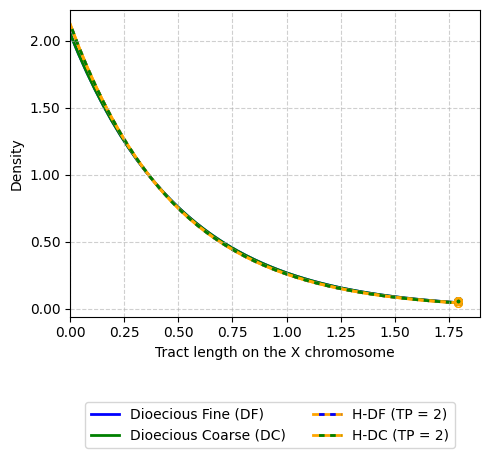

In [10]:
fig, ax = plot_tractlength_density(bins=newbins,
                                curves={'DF': density_df, 'DC': density_dc, 'H_DF': density_hp_df, 'H_DC': density_hp_dc},
                                L=which_L,
                                xlabel='Tract length on the X chromosome')
plt.show()

### 6.2 Plot histograms
#### 6.2.1 Plot for autosomal admixture
The following code produces a figure depicting all the computed Phase-Type histograms for autosomal admixture. Run if ``X_chr = False``.

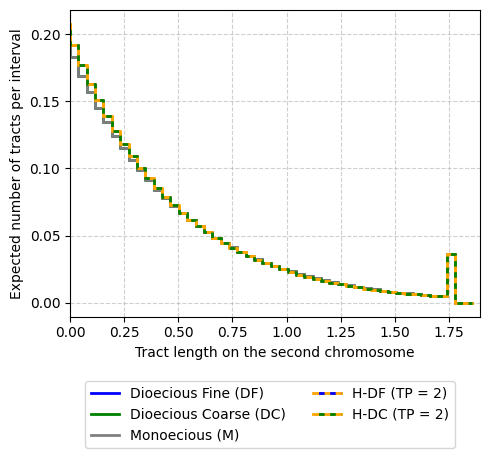

In [11]:
fig, ax = plot_tractlength_histogram(bins=bins,
                                    curves={'DF': hist_df, 'DC': hist_dc, 'M': hist_m, 'H_DF': hist_hp_df, 'H_DC': hist_hp_dc},
                                    xlabel='Tract length on the second chromosome',
                                    L=which_L)
plt.show()

#### 6.2.2 Plot for X chromosome admixture
The following code produces a figure depicting all the computed Phase-Type histograms for admixture on the X chromosome. Run if ``X_chr = True``.

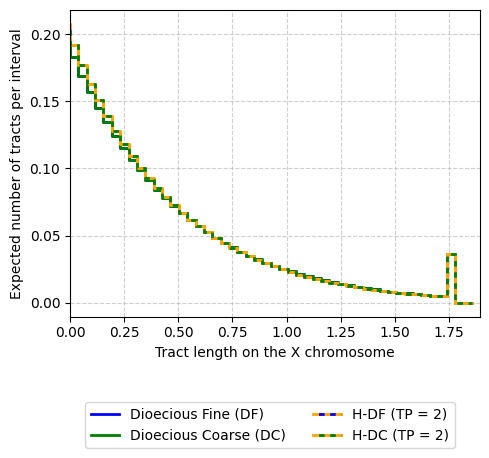

In [12]:
fig, ax = plot_tractlength_histogram(bins=bins,
                                    curves={'DF': hist_df, 'DC': hist_dc, 'H_DF': hist_hp_df, 'H_DC': hist_hp_dc},
                                    xlabel='Tract length on the X chromosome',
                                    L=which_L)
plt.show()

## 7. Continuous pulse during 15 generations
To conclude, we consider a more realistic scenario with the following migration matrix, letting the user specify the sex-bias parameters as in the previous example. Once again, ``whichpop`` sets the population of interest (0 or 1).

In [13]:
whichpop = 1
mig_matrix = np.array([[0, 0],[0.2, 0],[0.2, 0],[0.2, 0],[0.2, 0],[0.2, 0],[0.2, 0],[0.2, 0],[0.2, 0],[0.2, 0],[0.2, 0],[0.2, 0],[0.2, 0],[0.2, 0],[0.2, 0],[0, 1]])
print(np.shape(mig_matrix)[0]-1) # Number of generations

In [14]:
sex_bias = 0 # Sex-bias parameter, from -1 (exclusively male migration) to 1 (exclusively female migration). 0 corresponds to unbiased migration.
mig_f = mig_matrix + sex_bias*np.minimum(mig_matrix, 1-mig_matrix)
mig_m = mig_matrix - sex_bias*np.minimum(mig_matrix, 1-mig_matrix)
mig_m[-1,:] = mig_matrix[-1,:]
mig_f[-1,:] = mig_matrix[-1,:]

rho_f = 1 # Female-specific recombination rate
rho_m = 1 # Male-specific recombination rate

### 7.1 Monoecious model for autosomal admixture

In [15]:
PTmodel_mono = PhTMonoecious(migration_matrix=mig_matrix,
                            rho = 0.5*(rho_f+rho_m)) # PhTMonoecious object

# Phase-Type density (set freq = True for frequency scale)
newbins, density_m, E = PTmodel_mono.tractlength_histogram_windowed(population_number=whichpop,
                                                                    bins=bins,
                                                                    L=which_L,
                                                                    density=True,
                                                                    freq=False)
# Phase-type histogram
bins, hist_m, E = PTmodel_mono.tractlength_histogram_windowed(population_number=whichpop,
                                                            bins=bins,
                                                            L=which_L,
                                                            density=False,
                                                            freq=False)

#### 7.1.1 Plot density

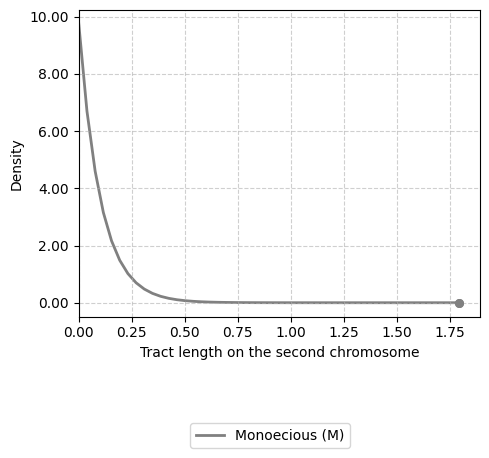

In [16]:
fig, ax = plot_tractlength_density(bins=newbins,
                                   curves={'M': density_m},
                                   L=which_L,
                                   xlabel='Tract length on the second chromosome')
plt.show()

#### 7.1.2 Plot histogram

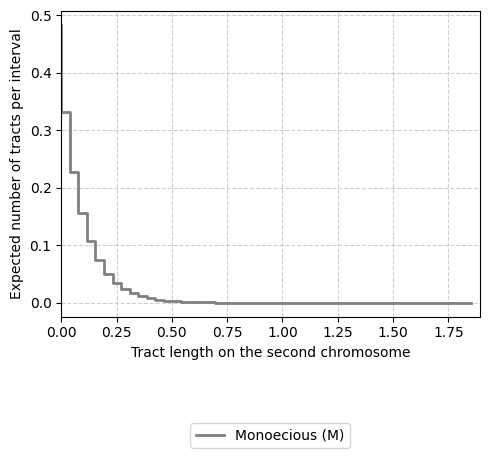

In [17]:
fig, ax = plot_tractlength_histogram(bins=bins,
                                    curves={'M': hist_m},
                                    xlabel='Tract length on the second chromosome',
                                    L=which_L)
plt.show()

### 7.2 H-DC model for X chromosome admixture

In [18]:
# The following lines can take a while to run, depending on the number of cores used and the size of the grid.

# Phase-Type mixture density for the H-DC model (set freq = True for frequency scale)
newbins, density_hp_dc = HP.hybrid_pedigree_distribution(mig_matrix_f=mig_f,
                                                        mig_matrix_m=mig_m,
                                                        TP=2,
                                                        Dioecious_model='DC',
                                                        L=which_L,
                                                        bingrid=bins,
                                                        whichpop=whichpop,
                                                        rho_f=rho_f,
                                                        rho_m=rho_m,
                                                        X_chr=True,
                                                        X_chr_male=False,
                                                        N_cores=5,
                                                        density=True,
                                                        freq=True)

# Phase-Type histogram for the H-DC model
bins, hist_hp_dc = HP.hybrid_pedigree_distribution(mig_matrix_f=mig_f,
                                                mig_matrix_m=mig_m,
                                                TP=2,
                                                Dioecious_model='DC',
                                                L=which_L,
                                                bingrid=bins,
                                                whichpop=whichpop,
                                                rho_f=rho_f,
                                                rho_m=rho_m,
                                                X_chr=True,
                                                X_chr_male=False,
                                                N_cores=5,
                                                density=False,
                                                freq=False)

#### 7.2.1 Plot density

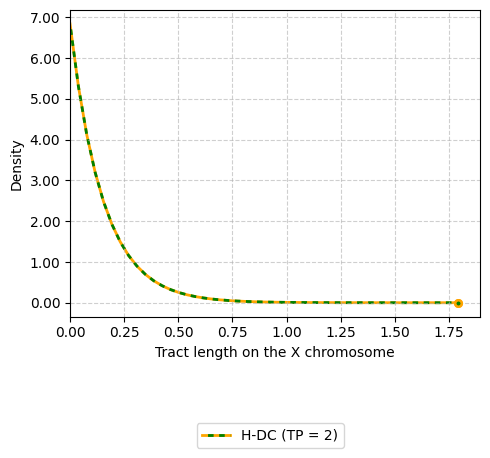

In [19]:
fig, ax = plot_tractlength_density(bins=newbins,
                                   curves={'H_DC': density_hp_dc},
                                   L=which_L,
                                   xlabel='Tract length on the X chromosome')
plt.show()

#### 7.2.2 Plot histogram

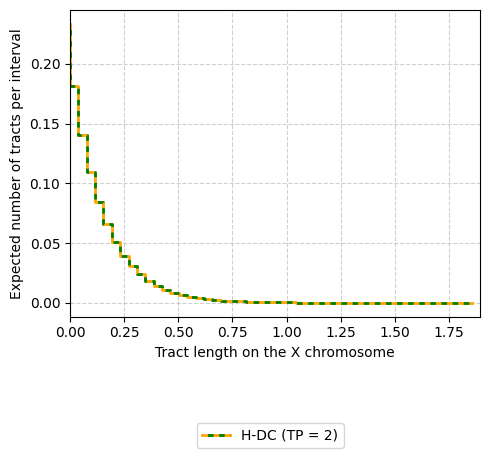

In [20]:
fig, ax = plot_tractlength_histogram(bins=bins,
                                    curves={'H_DC': hist_hp_dc},
                                    xlabel='Tract length on the X chromosome',
                                    L=which_L)
plt.show()